In [128]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import  Pipeline
from  sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import seaborn as sns
import matplotlib.pyplot as plt


In [129]:
df = pd.read_csv("../data/Cleaned_Housing_Dataset.csv")


In [130]:
df.info()

cat_col = df.select_dtypes(include='object').columns
numerical_col = df.select_dtypes(exclude='object').columns

ordinal_cols = [
    "LotShape",
    "LandSlope",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "OverallQual",
    "OverallCond"
]
nominal_cols = [
    "MSSubClass",
    "MSZoning",
    "Street",
    "Alley",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",
    "Heating",
    "CentralAir",
    "Electrical",
    "GarageType",
    "MiscFeature",
    "SaleType",
    "SaleCondition"
]


df["MSSubClass"] = df["MSSubClass"].astype("object")


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 96 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      1460 non-null   int64  
 1   Id              1460 non-null   int64  
 2   MSSubClass      1460 non-null   int64  
 3   MSZoning        1460 non-null   str    
 4   LotFrontage     1460 non-null   float64
 5   LotArea         1460 non-null   int64  
 6   Street          1460 non-null   str    
 7   Alley           1460 non-null   str    
 8   LotShape        1460 non-null   str    
 9   LandContour     1460 non-null   str    
 10  Utilities       1460 non-null   str    
 11  LotConfig       1460 non-null   str    
 12  LandSlope       1460 non-null   str    
 13  Neighborhood    1460 non-null   str    
 14  Condition1      1460 non-null   str    
 15  Condition2      1460 non-null   str    
 16  BldgType        1460 non-null   str    
 17  HouseStyle      1460 non-null   str    
 18 

C:\Users\Rupali Waghmare\AppData\Local\Temp\ipykernel_9768\2470842807.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include='object').columns


In [131]:
# ==========================================================
# Ordinal Encoding
# ==========================================================

quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

lotshape_map = {
    "Reg": 0,
    "IR1": 1,
    "IR2": 2,
    "IR3": 3
}

landslope_map = {
    "Gtl": 0,
    "Mod": 1,
    "Sev": 2
}

bsmtexposure_map = {
    "None": 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

bsmtfin_map = {
    "None": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

garagefinish_map = {
    "None": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

fence_map = {
    "None": 0,
    "MnWw": 1,
    "GdWo": 2,
    "MnPrv": 3,
    "GdPrv": 4
}

functional_map = {
    "Sal": 0,
    "Sev": 1,
    "Maj2": 2,
    "Maj1": 3,
    "Mod": 4,
    "Min2": 5,
    "Min1": 6,
    "Typ": 7
}

# Apply mappings

quality_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

for col in quality_cols:
    df[col] = df[col].map(quality_map)

df["LotShape"] = df["LotShape"].map(lotshape_map)

df["LandSlope"] = df["LandSlope"].map(landslope_map)

df["BsmtExposure"] = df["BsmtExposure"].map(bsmtexposure_map)

df["BsmtFinType1"] = df["BsmtFinType1"].map(bsmtfin_map)
df["BsmtFinType2"] = df["BsmtFinType2"].map(bsmtfin_map)

df["GarageFinish"] = df["GarageFinish"].map(garagefinish_map)

df["Fence"] = df["Fence"].map(fence_map)

df["Functional"] = df["Functional"].map(functional_map)

# OverallQual and OverallCond are already ordinal (1-10)
# No encoding required.


# ==========================================================
# One-Hot Encoding (Nominal Features)
# ==========================================================

nominal_cols = [
    "MSSubClass",
    "MSZoning",
    "Street",
    "Alley",
    "LandContour",
    "Utilities",
    "LotConfig",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",
    "Heating",
    "CentralAir",
    "Electrical",
    "GarageType",
    "MiscFeature",
    "SaleType",
    "SaleCondition"
]

ohe = OneHotEncoder(
    sparse_output=False,
    drop = "first",
    handle_unknown="ignore"
)

encoded = ohe.fit_transform(df[nominal_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(nominal_cols),
    index = df.index
)

df = df.drop(columns=nominal_cols)
df = pd.concat([df , encoded_df] , axis = 1)

In [132]:
print(df.shape)
print(df.columns.tolist())

(1460, 232)
['Unnamed: 0', 'Id', 'LotFrontage', 'LotArea', 'LotShape', 'LandSlope', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'TotalSF', 'HouseAge', 'RemodelAge', 'GarageAge', 'TotalBathrooms', 'TotalPorchSF', 'TotalOutdoorSF', 'HasGarage', 'HasBasement', 'HasFireplace', 'HasPool', 'Has2ndFloor', 'HasRemodel', 'LotAreaPerRoom', 'MSSubC

In [133]:
df.to_csv("../data/Encoded_Cleaned_Housing_Dataset.csv") # this dataset will be used for train test split

raw = pd.read_csv('../data/Cleaned_Housing_Dataset.csv'); # This will be used for mutual info regression scores
# This will be used because it dont have encoded columns

In [134]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_regression

# ==========================================================
# Prepare data for MI
# ==========================================================

X_mi = raw.drop("SalePrice", axis=1)
y = raw["SalePrice"]

# Get categorical columns
cat_cols = X_mi.select_dtypes(include="object").columns

# Boolean mask for categorical features
discrete_cols = X_mi.columns.isin(cat_cols)

# Temporary encoding ONLY for MI calculation
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_mi[cat_cols] = encoder.fit_transform(X_mi[cat_cols])

# ==========================================================
# Calculate MI
# ==========================================================

mi_values = mutual_info_regression(
    X_mi,
    y,
    discrete_features=discrete_cols,
    random_state=42
)

# Convert MI scores to Series
mi_scores = pd.Series(
    mi_values,
    index=X_mi.columns
).sort_values(ascending=False)

print(mi_scores)

# ==========================================================
# Top 10 ORIGINAL features
# ==========================================================

top_10_features = mi_scores.head(10).index.tolist()

print("\nTop 10 features:")
print(top_10_features)

# ==========================================================
# Map original features → encoded columns
# ==========================================================

selected_cols = []

for feature in top_10_features:

    # Feature exists directly in encoded df
    if feature in df.columns:
        selected_cols.append(feature)

    # Feature was one-hot encoded
    else:
        selected_cols.extend([
            col for col in df.columns
            if isinstance(col, str)
               and col.startswith(feature + "_")
        ])

# ==========================================================
# Final X and y
# ==========================================================

X = df[selected_cols]
y = df["SalePrice"]

print("\nSelected columns:")
print(selected_cols)

print("\nX shape:", X.shape)

C:\Users\Rupali Waghmare\AppData\Local\Temp\ipykernel_9768\2120101656.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_mi.select_dtypes(include="object").columns


TotalSF         0.676690
OverallQual     0.552786
Neighborhood    0.527471
GrLivArea       0.482193
YearBuilt       0.369157
                  ...   
Id              0.000000
Unnamed: 0      0.000000
YrSold          0.000000
PoolQC          0.000000
MoSold          0.000000
Length: 95, dtype: float64

Top 10 features:
['TotalSF', 'OverallQual', 'Neighborhood', 'GrLivArea', 'YearBuilt', 'TotalBsmtSF', 'GarageCars', 'GarageArea', 'TotalBathrooms', 'HouseAge']

Selected columns:
['TotalSF', 'OverallQual', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somers

In [135]:


X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    shuffle=True,
    random_state=42
)

pipelines = [
    Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ]),

    Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Ridge())
    ]),

    Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Lasso(max_iter=10000))
    ]),

    Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", SVR())
    ]),

    Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", KNeighborsRegressor())
    ])
]

for pipeline in pipelines:

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    print(
        pipeline.named_steps["regressor"].__class__.__name__,
        scores.mean()
    )

param_grids = [
    {
        "regressor__fit_intercept" : [True , False]
    },
    {
        "regressor__alpha" : [0.01, 0.1, 1, 10, 100]
    },
    {
        "regressor__alpha" : [0.001, 0.01, 0.1, 1, 10]
    },
    {
        "regressor__C" : [0.1 , 1 ,10 ,100],
        "regressor__kernel":["linear" , "rbf"],
        "regressor__gamma" : ["scale" , "auto"]
    },

    {
        "regressor__n_neighbors": [3, 5, 7, 10, 15, 20],
        "regressor__weights": ["uniform", "distance"],
        "regressor__p": [1, 2]
    }
]

LinearRegression 0.7489582252488857
Ridge 0.750517454437919
Lasso 0.7490519618645821
SVR -0.04611871747634555
KNeighborsRegressor 0.7663432265410587


In [136]:
grid_results = []
metrics_results = []

for pipeline, param_grid in zip(pipelines, param_grids):

    start_time = time.time()

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    training_time = time.time() - start_time

    # Store the entire GridSearchCV object
    grid_results.append(grid)

    # Best fitted pipeline
    best_model = grid.best_estimator_

    # Test prediction
    y_pred = best_model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    model_name = (
        pipeline
        .named_steps["regressor"]
        .__class__
        .__name__
    )

    metrics_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "CV Score": grid.best_score_,
        "Training Time": training_time
    })

results_df = pd.DataFrame(metrics_results)

results_df

,Model,MAE,RMSE,R²,CV Score,Training Time
0,LinearRegression,21812.025642,34234.768759,0.832043,0.748958,10.840441
1,Ridge,21361.733615,34253.089714,0.831863,0.760650,6.707763
2,Lasso,21701.639763,34138.930800,0.832982,0.749884,0.229827
3,SVR,21209.790126,37271.479279,0.800925,0.756695,0.401480
4,KNeighborsRegressor,19339.927766,30628.048286,0.865568,0.776848,0.865706


In [137]:
import joblib

best_grid = max(
    grid_results,
    key=lambda grid: grid.best_score_
)

best_pipeline = best_grid.best_estimator_

joblib.dump(best_pipeline, "house_price_model.joblib")

['house_price_model.joblib']

# **Comparison within Models**

# **1. R² + CV R² comparison**

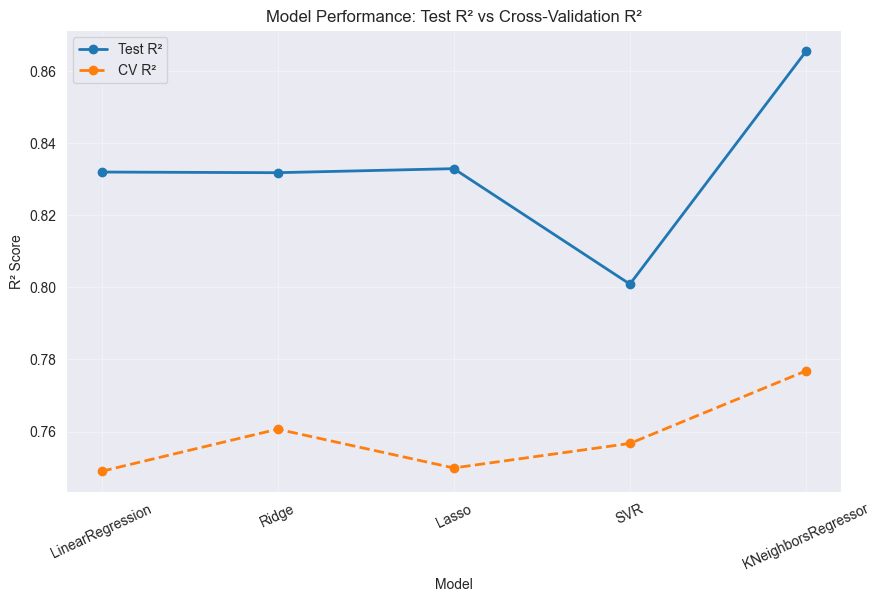

In [138]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df["Model"],
    results_df["R²"],
    marker="o",
    linewidth=2,
    label="Test R²"
)

plt.plot(
    results_df["Model"],
    results_df["CV Score"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="CV R²"
)

plt.title("Model Performance: Test R² vs Cross-Validation R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=25)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

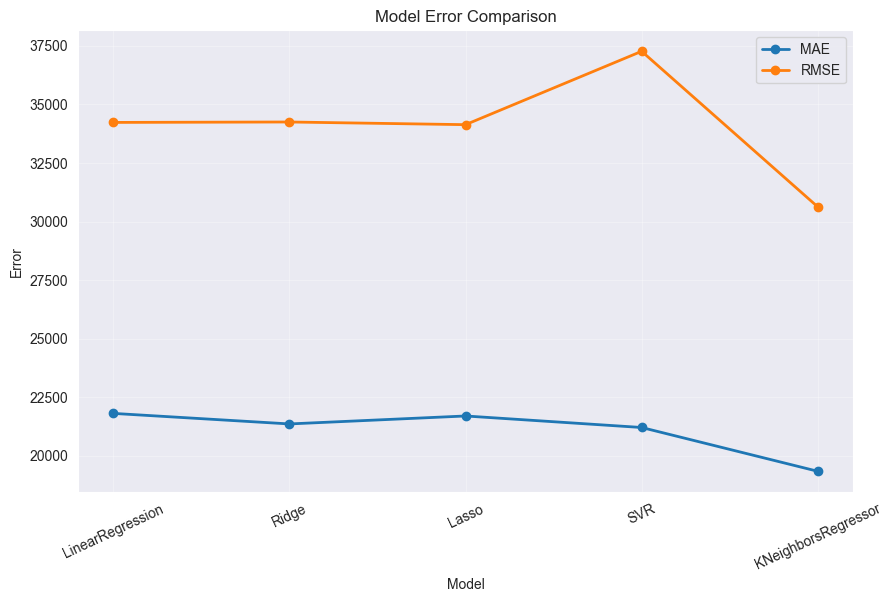

In [139]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df["Model"],
    results_df["MAE"],
    marker="o",
    linewidth=2,
    label="MAE"
)

plt.plot(
    results_df["Model"],
    results_df["RMSE"],
    marker="o",
    linewidth=2,
    label="RMSE"
)

plt.title("Model Error Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=25)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# **Actual vs Predicted — KNN Regressor**

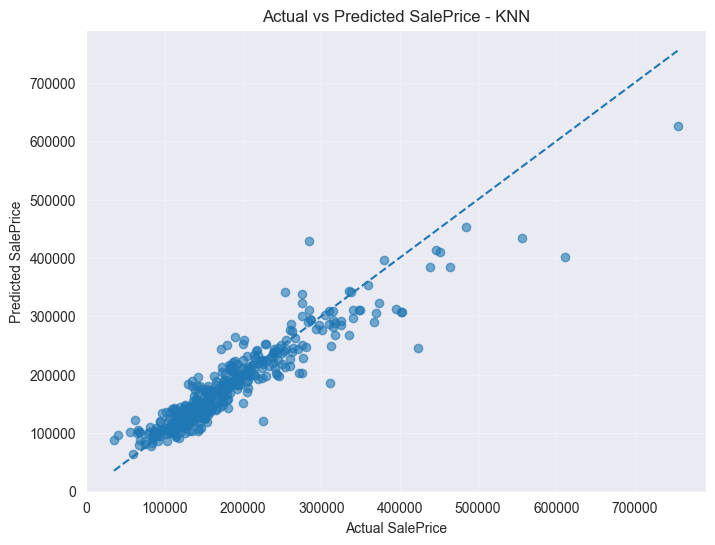

In [140]:
best_grid = max(grid_results, key=lambda x: x.best_score_)
best_model = best_grid.best_estimator_

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice - KNN")
plt.grid(True, alpha=0.3)

plt.show()

## **Residual Plot**

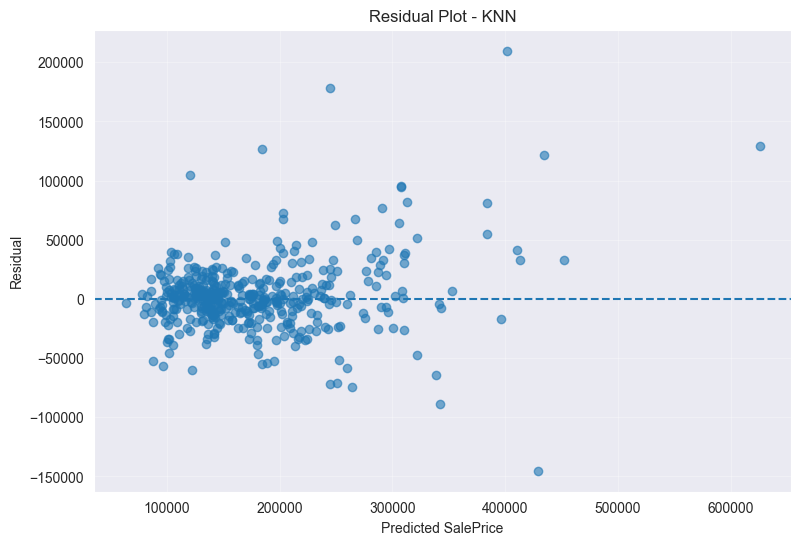

In [141]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residual Plot - KNN")
plt.grid(True, alpha=0.3)

plt.show()

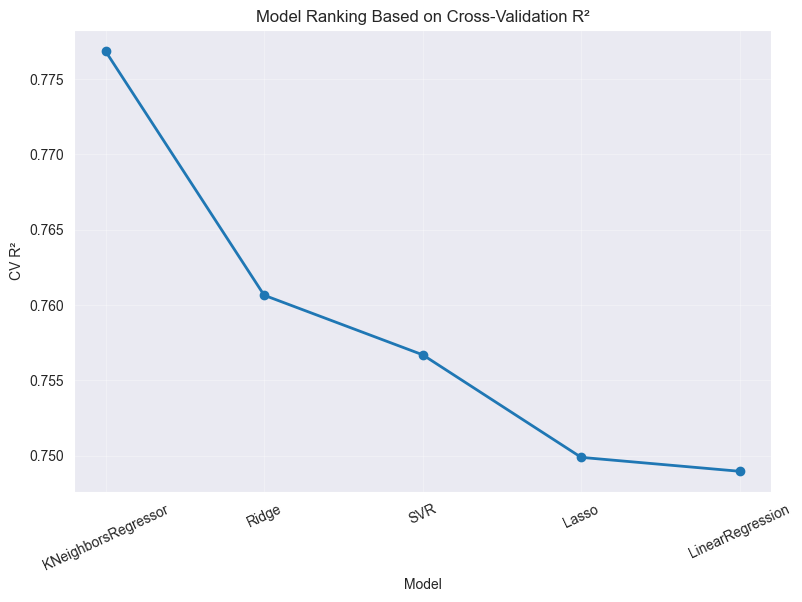

In [142]:
sorted_results = results_df.sort_values(
    "CV Score",
    ascending=False
)

plt.figure(figsize=(9, 6))

plt.plot(
    sorted_results["Model"],
    sorted_results["CV Score"],
    marker="o",
    linewidth=2
)

plt.xlabel("Model")
plt.ylabel("CV R²")
plt.title("Model Ranking Based on Cross-Validation R²")
plt.xticks(rotation=25)
plt.grid(True, alpha=0.3)

plt.show()